In [ ]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager
from src.evaluation import Evaluator
from src.configmanagement.experimentconfigmanager import ExperimentRunner


disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1


config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',    
    )       
data_orchestrator = DataOrchestrator(config).build()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

n_epochs        = 1
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }


# Usage:
runner = (ExperimentRunner(data_orchestrator, verbose = 2)
    .add_baseline_model('PersistenceModel', 'persistence')
    .add_baseline_model('ClimateologyModel', 'climateology')    
    .add_gnn('NodeGRUModel',    'nodegru',          'identity_graph',                       global_hparams=global_hparams)
    # .add_gnn('NodeLSTMModel',   'nodelstm',         'identity_graph',                       global_hparams=global_hparams)        
    # .add_gnn('NodeBiLSTMModel', 'nodebilstm',       'identity_graph',                       global_hparams=global_hparams, hidden_size = 8, num_layers=1)                        
)

results = runner.run()


==                 persistence                  ==
forecasted ✓

==                 climateology                 ==
forecasted ✓

==                   nodegru                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))


AttributeError: 'tuple' object has no attribute 'dim'

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


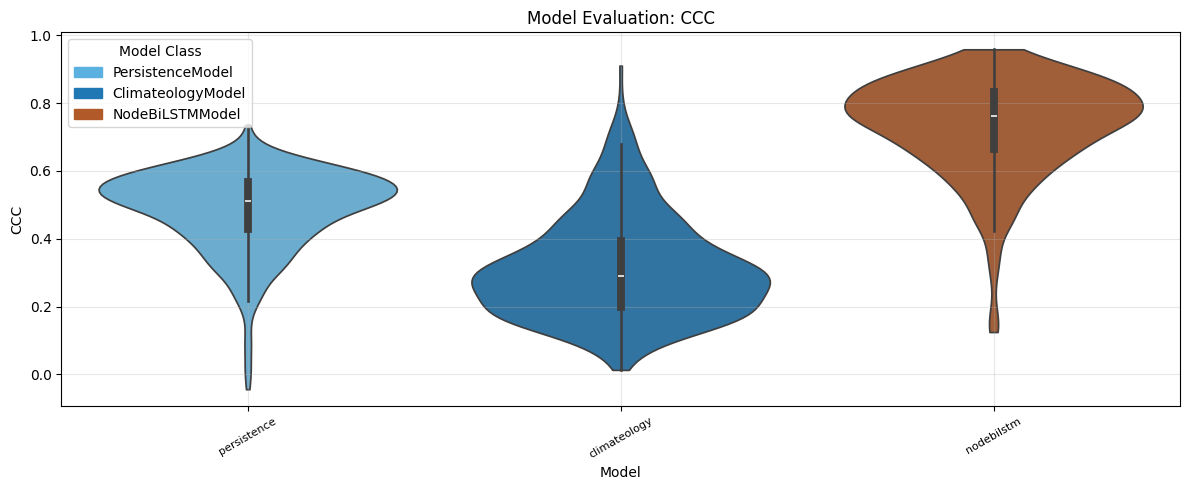

In [13]:
runner.evaluation.plotter.plot_metric('ccc', horizon = 'horizon_0')